# Codveda Data Analytics Internship - Level 3 (Advanced)

This notebook completes all Level 3 tasks from the provided internship PDF:

- Task 1: Predictive Modeling (Classification)
- Task 2: Building a Dashboard
- Task 3: Natural Language Processing (NLP) - Sentiment Analysis

Note: the PDF names Power BI/Tableau for dashboards. Because this project is notebook-based, this notebook creates an interactive Plotly dashboard and exports it as an HTML report.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from wordcloud import WordCloud

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from textblob import TextBlob

sns.set_theme(style="whitegrid", palette="Set2")

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("outputs/level_3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Task 1: Predictive Modeling (Classification)

In [2]:
# Load the provided churn train/test split.
train_df = pd.read_csv(DATA_DIR / "churn-bigml-80.csv")
test_df = pd.read_csv(DATA_DIR / "churn-bigml-20.csv")

def clean_churn_columns(data):
    cleaned = data.copy()
    cleaned.columns = (
        cleaned.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
    )
    for col in cleaned.select_dtypes(include="object").columns:
        cleaned[col] = cleaned[col].astype(str).str.strip()
    cleaned["churn"] = cleaned["churn"].astype(bool)
    return cleaned

train_df = clean_churn_columns(train_df)
test_df = clean_churn_columns(test_df)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (2666, 20)
Test shape: (667, 20)


,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
# Separate features and target.
target = "churn"
X_train = train_df.drop(columns=target)
y_train = train_df[target]
X_test = test_df.drop(columns=target)
y_test = test_df[target]

categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

# OneHotEncoder changed the sparse parameter name in newer scikit-learn versions, so this is version-safe.
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", encoder, categorical_features),
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=200),
}

results = []
fitted_models = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, preds, average="binary", zero_division=0
    )
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    })
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
results_df

,model,accuracy,precision,recall,f1_score
2,Random Forest,0.941529,0.982759,0.600000,0.745098
1,Decision Tree,0.923538,0.750000,0.694737,0.721311
0,Logistic Regression,0.779610,0.368687,0.768421,0.498294


In [4]:
# Hyperparameter tuning with GridSearchCV for Random Forest.
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 8, 14],
    "model__min_samples_split": [2, 5],
}

grid = GridSearchCV(
    rf_pipe, param_grid=param_grid, cv=3, scoring="f1", n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
best_preds = best_model.predict(X_test)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 3))
print("Test classification report:")
print(classification_report(y_test, best_preds, zero_division=0))

Best parameters: {'model__max_depth': 8, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV F1: 0.747
Test classification report:
              precision    recall  f1-score   support

       False       0.96      0.97      0.96       572
        True       0.78      0.76      0.77        95

    accuracy                           0.94       667
   macro avg       0.87      0.86      0.87       667
weighted avg       0.93      0.94      0.94       667



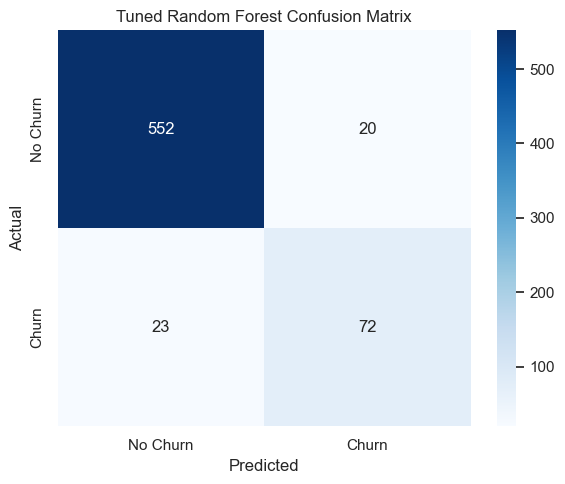

In [5]:
# Confusion matrix for the tuned model.
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=ax)
ax.set_title("Tuned Random Forest Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "classification_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 2: Interactive Dashboard

In [6]:
# Prepare aggregated data for an interactive dashboard.
dashboard_df = train_df.copy()
dashboard_df["churn_label"] = np.where(dashboard_df["churn"], "Churn", "No Churn")

plan_rate = dashboard_df.groupby("international_plan", as_index=False)["churn"].mean()
plan_rate["churn_rate_pct"] = plan_rate["churn"] * 100

service_rate = dashboard_df.groupby("customer_service_calls", as_index=False)["churn"].mean()
service_rate["churn_rate_pct"] = service_rate["churn"] * 100

state_rate = (
    dashboard_df.groupby("state", as_index=False)["churn"]
    .agg(churn_rate="mean", customers="count")
    .sort_values("churn_rate", ascending=False)
    .head(12)
)
state_rate["churn_rate_pct"] = state_rate["churn_rate"] * 100

In [7]:
# Build an interactive Plotly dashboard and export it as HTML.
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "bar"}, {"type": "scatter"}], [{"type": "bar"}, {"type": "pie"}]],
    subplot_titles=(
        "Churn Rate by International Plan",
        "Churn Rate by Customer Service Calls",
        "Top States by Churn Rate",
        "Overall Churn Split"
    )
)

fig.add_trace(go.Bar(x=plan_rate["international_plan"], y=plan_rate["churn_rate_pct"], name="Plan churn"), row=1, col=1)
fig.add_trace(go.Scatter(x=service_rate["customer_service_calls"], y=service_rate["churn_rate_pct"], mode="lines+markers", name="Service calls"), row=1, col=2)
fig.add_trace(go.Bar(x=state_rate["state"], y=state_rate["churn_rate_pct"], name="State churn"), row=2, col=1)
fig.add_trace(go.Pie(labels=dashboard_df["churn_label"].value_counts().index, values=dashboard_df["churn_label"].value_counts().values, name="Churn split"), row=2, col=2)

fig.update_layout(
    title_text="Customer Churn Interactive Dashboard",
    height=800,
    showlegend=False,
    template="plotly_white"
)
fig.update_yaxes(title_text="Churn Rate (%)", row=1, col=1)
fig.update_yaxes(title_text="Churn Rate (%)", row=1, col=2)
fig.update_yaxes(title_text="Churn Rate (%)", row=2, col=1)

dashboard_path = OUTPUT_DIR / "customer_churn_dashboard.html"
fig.write_html(dashboard_path)
print("Dashboard exported to:", dashboard_path)
fig.show()

Dashboard exported to: outputs\level_3\customer_churn_dashboard.html


## Task 3: NLP - Sentiment Analysis

In [8]:
# Load the sentiment dataset and clean text fields.
sentiment_df = pd.read_csv(DATA_DIR / "3) Sentiment dataset.csv")
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)

# Remove unnamed index-like columns if they exist.
sentiment_df = sentiment_df.loc[:, ~sentiment_df.columns.str.startswith("unnamed")]
sentiment_df["text"] = sentiment_df["text"].fillna("").astype(str).str.strip()
sentiment_df["sentiment"] = sentiment_df["sentiment"].fillna("Unknown").astype(str).str.strip()

print("Sentiment dataset shape:", sentiment_df.shape)
sentiment_df[["text", "sentiment", "platform", "country"]].head()

Sentiment dataset shape: (732, 13)


,text,sentiment,platform,country
0,Enjoying a beautiful day at the park!,Positive,Twitter,USA
1,Traffic was terrible this morning.,Negative,Twitter,Canada
2,Just finished an amazing workout! 💪,Positive,Instagram,USA
3,Excited about the upcoming weekend getaway!,Positive,Facebook,UK
4,Trying out a new recipe for dinner tonight.,Neutral,Instagram,Australia


In [9]:
# Text preprocessing: tokenization, stopword removal, and stemming.
stemmer = PorterStemmer()
stop_words = set(ENGLISH_STOP_WORDS)

def preprocess_text(text):
    tokens = re.findall(r"[a-zA-Z]+", text.lower())
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    stems = [stemmer.stem(token) for token in tokens]
    return " ".join(stems)

sentiment_df["clean_text"] = sentiment_df["text"].apply(preprocess_text)

sentiment_df[["text", "clean_text"]].head()

,text,clean_text
0,Enjoying a beautiful day at the park!,enjoy beauti day park
1,Traffic was terrible this morning.,traffic terribl morn
2,Just finished an amazing workout! 💪,just finish amaz workout
3,Excited about the upcoming weekend getaway!,excit upcom weekend getaway
4,Trying out a new recipe for dinner tonight.,tri new recip dinner tonight


In [10]:
# Use TextBlob polarity to classify each text as positive, negative, or neutral.
def textblob_label(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.05:
        return "positive"
    if polarity < -0.05:
        return "negative"
    return "neutral"

sentiment_df["textblob_polarity"] = sentiment_df["text"].apply(lambda text: TextBlob(text).sentiment.polarity)
sentiment_df["textblob_sentiment"] = sentiment_df["text"].apply(textblob_label)

sentiment_df[["text", "sentiment", "textblob_polarity", "textblob_sentiment"]].head(10)

,text,sentiment,textblob_polarity,textblob_sentiment
0,Enjoying a beautiful day at the park!,Positive,0.750000,positive
1,Traffic was terrible this morning.,Negative,-1.000000,negative
2,Just finished an amazing workout! 💪,Positive,0.750000,positive
3,Excited about the upcoming weekend getaway!,Positive,0.468750,positive
4,Trying out a new recipe for dinner tonight.,Neutral,0.136364,positive
5,Feeling grateful for the little things in life.,Positive,-0.187500,negative
6,Rainy days call for cozy blankets and hot cocoa.,Positive,0.025000,neutral
7,The new movie release is a must-watch!,Positive,0.170455,positive
8,Political discussions heating up on the timeline.,Negative,0.000000,neutral
9,Missing summer vibes and beach days.,Neutral,-0.200000,negative


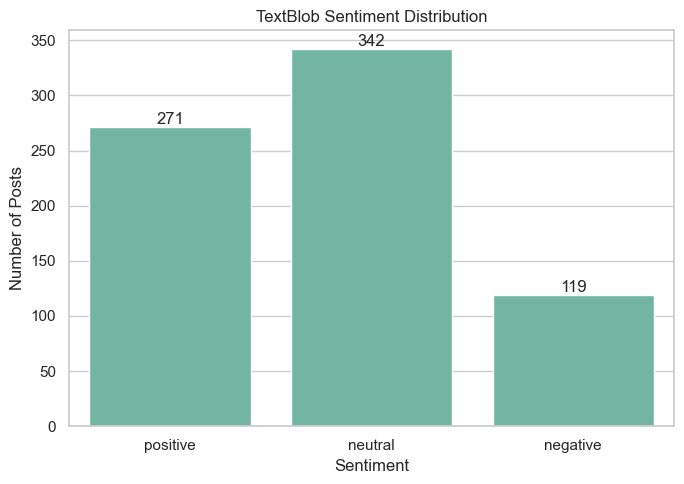

In [11]:
# Visualize TextBlob sentiment distribution.
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=sentiment_df, x="textblob_sentiment", order=["positive", "neutral", "negative"], ax=ax)
ax.set_title("TextBlob Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Posts")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "textblob_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

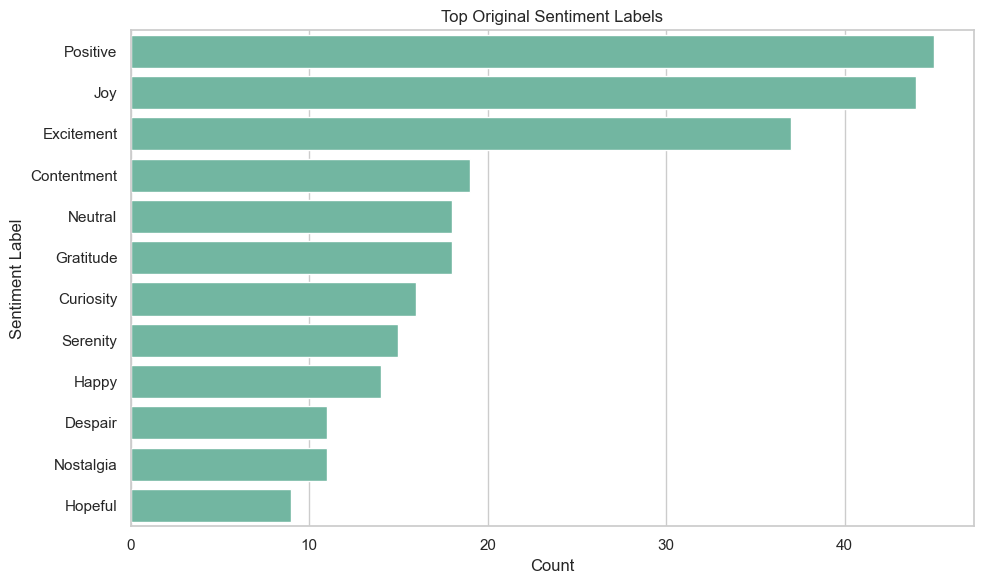

In [12]:
# Visualize the original dataset sentiment labels.
top_sentiments = sentiment_df["sentiment"].value_counts().head(12).reset_index()
top_sentiments.columns = ["sentiment", "count"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_sentiments, y="sentiment", x="count", ax=ax)
ax.set_title("Top Original Sentiment Labels")
ax.set_xlabel("Count")
ax.set_ylabel("Sentiment Label")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "original_sentiment_labels.png", dpi=150, bbox_inches="tight")
plt.show()

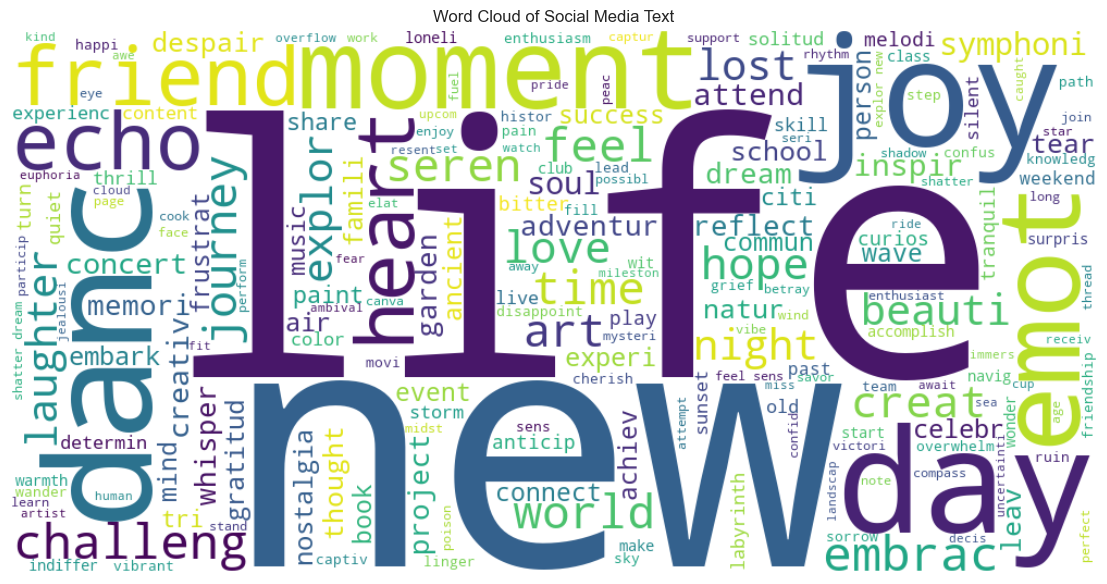

In [13]:
# Word cloud of cleaned text shows the most frequent words after preprocessing.
all_words = " ".join(sentiment_df["clean_text"].dropna())
wordcloud = WordCloud(width=1000, height=500, background_color="white", colormap="viridis").generate(all_words)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud of Social Media Text")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "sentiment_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Engagement comparison by TextBlob sentiment.
engagement = sentiment_df.groupby("textblob_sentiment")[["likes", "retweets"]].mean().round(2)
engagement

,likes,retweets
textblob_sentiment,,
negative,37.46,18.81
neutral,41.80,20.95
positive,46.68,23.39


## Level 3 Findings

- The tuned Random Forest gives the best balanced churn classification performance among the tested models.
- The dashboard highlights churn concentration by international plan, service-call volume, and state.
- TextBlob sentiment analysis creates positive/neutral/negative classes, while the original dataset contains many emotion-style labels such as joy, excitement, sadness, and gratitude.